# Microphone data analysis

Read tab-seperated compressed Picoscope microphone data and calculate ensemble average spectra.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2024 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 11/12/2025
    
    Multiphase Flow Laboratory
    Monash University, Australia


In [133]:
import gzip, os
from scipy.signal import welch, spectrogram
from scipy.integrate import simpson
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
def read_pico_txt(filename):
    ''' Read tab seperated text file exported from PicoScope T&M Software '''
    if os.path.splitext(filename)[-1] == '.gz': #.txt.gz
        F=gzip.open(filename, 'rb')
    elif os.path.splitext(filename)[-1] == '.txt':
        F=open(filename,'rb')
    else:
        print("Unknown/unsupported file type")
    header=[]
    data=[]
    inheader=True
    for line in F.readlines():
        l=line.decode('ascii').strip()
        if l=='': inheader=False
        else:
            if inheader: header.append(l.split("\t"))
            else: data.append([float(v) for v in l.split("\t")])
    F.close()
    return header, np.array(data)

In [15]:
def findEnvelope(data, smoothing=None):
    ''' Apply a smoothing to the data and find the amplitude envelope.
        Then determine the largest contiguous period of signal. '''
    # default smoothing window as fraction of total time series
    if smoothing is None: smoothing=int(data.shape[0]/25)
    kernel = np.hanning(smoothing)
    kernel /= np.sum(kernel)
    env = np.convolve(data[:,1]**2, kernel, 'same')
    # env = np.sqrt(env)
    
    # mask out start and end regions
    env[:smoothing]=np.nan
    env[-smoothing:]=np.nan

    # normalize by starting background
    env /= np.nanmean(env[data[:,0]<np.nanmin(data[:,0]/2)])

    # Check signal to noise ratio
    snr = np.nanmax(env)
    if (snr<1.5): 
        print("No signal found in time series")
        return None, None
    else:
        print("Good signal, SNR=%g" % snr)

    # Time range of spray
    sprayOn = env>=1.5

    # Largest contiguous region
    transitions = np.where(np.diff(sprayOn)!=0)[0]
    idx=np.where(np.diff(transitions)==np.nanmax(np.diff(transitions)))[0][0]
    sprayOnIndices = transitions[idx:idx+2]
    print("valid spray from t=%f-%f" % tuple(data[sprayOnIndices,0]))
    
    return env, snr, sprayOnIndices

## Process one case

In [171]:
header, data = read_pico_txt('/Users/dduke/Desktop/microphone/R134a_placebo_BK327-0002/R134a_placebo_BK327-0002_02.txt.gz')
envelope, snr, t_valid = findEnvelope(data)
Psat = 6.7e5
Pamb = 1.01e5
Dnoz = 3e-4
rhoMix = 16.3

Good signal, SNR=20.5606
valid spray from t=-8.124394-58.555312


### Plot timeseries and envelope

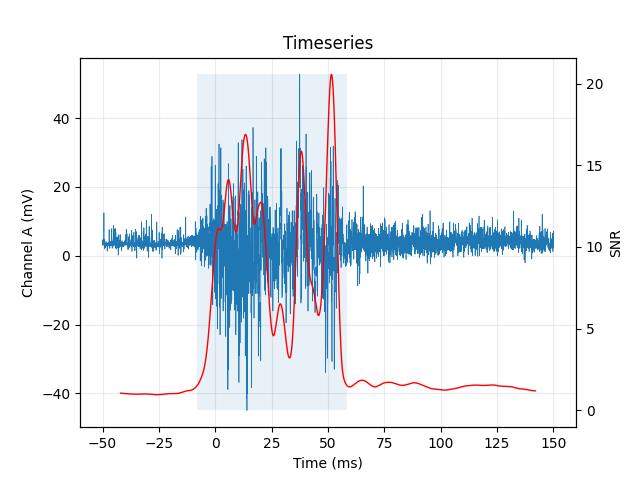

In [172]:
fig=plt.figure()
plt.plot(data[::100,0],data[::100,1],lw=.5)
plt.grid(alpha=.25);
plt.xlabel("%s %s" % (header[0][0], header[1][0]))
plt.ylabel("%s %s" % (header[0][1], header[1][1]))
plt.twinx()
plt.plot(data[:,0],envelope,lw=1,c='r')
plt.fill_between(data[t_valid,0],[0, 0],[snr, snr],alpha=.1)
plt.ylabel("SNR")
plt.title("Timeseries")
plt.show();

## Spectral analysis

In [173]:
samplingFreq = 1e3/np.nanmean(np.diff(data[:,0])) # Hz, assuming ms in source
print('dt=',1e6*np.nanmean(np.diff(data[:,0])),'±', 1e6*np.nanstd(np.diff(data[:,0])), 'ns')
print('mean freq = %g MHz' % (samplingFreq/1e6))

# Time-averaged welch spectra
fb, Pbb = welch(data[:t_valid[0],1], fs=samplingFreq, detrend='linear')
fs, Pss = welch(data[t_valid[0]:t_valid[1],1], fs=samplingFreq)
Pbr = Pss/Pbb
Pbr /= simpson(Pbr, x=fs)
Pbr[Pbr<=0]=np.nan

Un = np.sqrt(2*(Psat-Pamb)/rhoMix) # sqrt(2*∆P/rho_mix)
St_b = fb * Dnoz / Un # Strouhal number

# Spectrogram (time dependence)
fwb,twb, spectrb =spectrogram(data[:t_valid[0],1], fs=samplingFreq, nperseg=512)  # bkgnd
spectrb_tavg = np.nanmean(spectrb,axis=1)
fw, tw, spectro = spectrogram(data[t_valid[0]:t_valid[1],1], fs=samplingFreq, nperseg=512) # spray
spectro_bkrmv = np.zeros_like(spectro)  # remove pre-spray background spectrum
for i in range(spectro.shape[1]):
    spectro_bkrmv[:,i] = spectro[:,i] / spectrb_tavg
    spectro_bkrmv[:,i] /= simpson(spectro_bkrmv[:,i], x=fw)
St_s = fw * Ln / Un # Strouhal number

dt= 504.00001328031294 ± 0.0003641795685675314 ns
mean freq = 1.98413 MHz


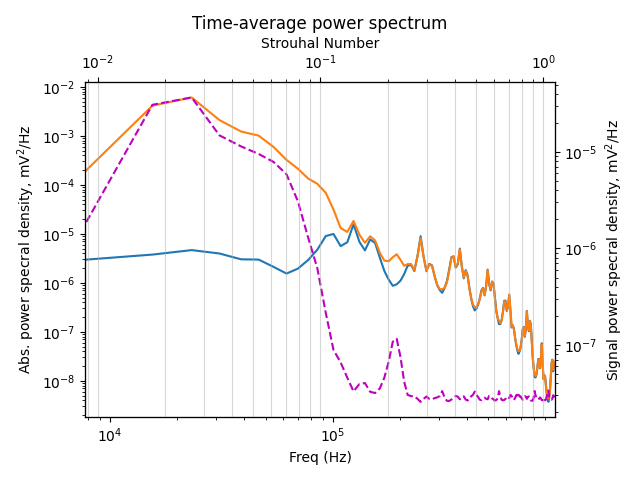

In [174]:
fig=plt.figure()
plt.loglog(f,Pbb)
plt.loglog(f,Pss)
plt.title("Time-average power spectrum")
plt.xlabel("Freq (Hz)")
plt.ylabel("Abs. power specral density, mV$^2$/Hz")
plt.twinx()
plt.ylabel("Signal power specral density, mV$^2$/Hz")
plt.loglog(f,Pbr,c='m',ls='--')
plt.xlim(f[f>0].min(),f.max())
plt.twiny()
plt.xlabel("Strouhal Number")
plt.gca().set_xscale('log')
plt.xlim(St_b[St_b>0].min(),St_b.max())
plt.grid(alpha=.5,which='both')
plt.tight_layout();
plt.show();

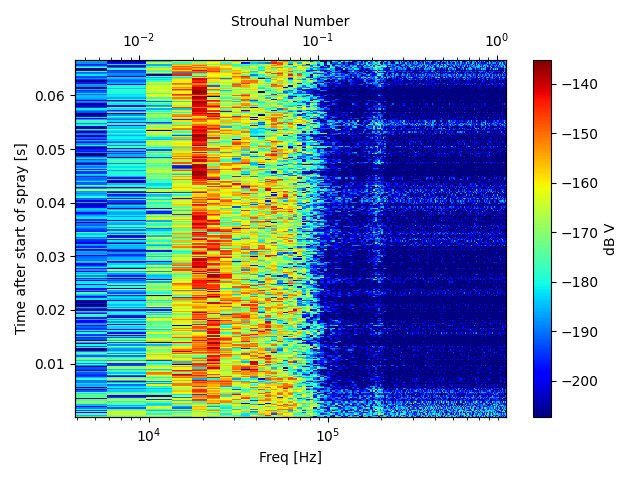

In [175]:
fig=plt.figure()
tt,ff=np.meshgrid(tw,fw)
spectro_dbV  = 20*np.log10(spectro_bkrmv*1e-3)

p=plt.pcolormesh(ff,tt,spectro_dbV,vmin=np.mean(spectro_dbV),cmap='jet');
plt.xlim(ff[ff>0].min(),ff.max())
plt.gca().set_xscale('log')
plt.xlabel('Freq [Hz]')
plt.ylabel('Time after start of spray [s]')
plt.colorbar(p,label='dB V');

plt.twiny()
plt.xlabel("Strouhal Number")
plt.gca().set_xscale('log')
plt.xlim(St_s[St_s>0].min(),St_s.max())
plt.tight_layout();
